# 02 — Anomaly Detection Models
### Winding Process Anomaly Detection Project
---
**Goal:** Detect abnormal winding cycles using three approaches of increasing complexity.  
**Models:** Z-score baseline · Logistic Regression · Random Forest Classifier  
**Metrics:** Precision · Recall · F1 · AUC · Confusion Matrix


In [14]:
import os
os.chdir(os.path.dirname(os.path.abspath('02_AnomalyDetection.ipynb')))
print("Working directory:", os.getcwd())


Working directory: d:\Downloads\Winding Anomaly Detection Project\winding-anomaly-detection\notebooks


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.decomposition import PCA

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
    'font.size':11,'axes.titlesize':12,
})
os.makedirs('../results/plots', exist_ok=True)
os.makedirs('../src', exist_ok=True)
SEED = 42
np.random.seed(SEED)
print("Imports OK.")


Imports OK.


## 1. Load Data

In [16]:
df = pd.read_csv('../data/raw/winding_anomaly_data.csv')

SIGNAL_FEATURES = [
    'tension_mean_N','tension_std_N','tension_peak_N',
    'power_mean_W','power_std_W',
    'temp_max_C','temp_gradient','winding_speed_rpm'
]

X = df[SIGNAL_FEATURES]
y = df['is_anomaly'].values

print(f"Total cycles   : {len(df)}")
print(f"Normal cycles  : {(y==0).sum()}")
print(f"Anomaly cycles : {(y==1).sum()}")
print(f"Anomaly rate   : {y.mean()*100:.1f}%")


Total cycles   : 500
Normal cycles  : 400
Anomaly cycles : 100
Anomaly rate   : 20.0%


## 2. Preprocessing — Scale Features

The scaler is fitted on the full dataset here because we are running a supervised
classifier that sees both normal and anomaly labels during training.
This is different from unsupervised detection where you would fit only on normal data.


In [17]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=SIGNAL_FEATURES)

joblib.dump(scaler, '../src/anomaly_scaler.pkl')
print("Scaler fitted and saved.")
print(f"Sample means after scaling (should be ~0):")
print(X_scaled.mean().round(3).to_string())


Scaler fitted and saved.
Sample means after scaling (should be ~0):
tension_mean_N      -0.0
tension_std_N       -0.0
tension_peak_N       0.0
power_mean_W        -0.0
power_std_W          0.0
temp_max_C          -0.0
temp_gradient       -0.0
winding_speed_rpm   -0.0


## 3. Train / Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Train : {len(X_train)} samples  failure rate: {y_train.mean()*100:.1f}%")
print(f"Test  : {len(X_test)} samples   failure rate: {y_test.mean()*100:.1f}%")


Train : 400 samples  failure rate: 20.0%
Test  : 100 samples   failure rate: 20.0%


## 4. Model 1 — Z-score Statistical Baseline

In [19]:
# Compute mean and std from training normal cycles only
normal_mask = y_train == 0
train_mean = X_train[normal_mask].mean()
train_std  = X_train[normal_mask].std()

# Flag a cycle if any feature exceeds 3 standard deviations
Z_THRESHOLD = 3.0
z_scores  = np.abs((X_test - train_mean) / (train_std + 1e-9))
z_max     = z_scores.max(axis=1)
z_pred    = (z_max > Z_THRESHOLD).astype(int)

print(f"Z-score threshold : {Z_THRESHOLD}")
print(f"Flagged anomalies : {z_pred.sum()} / {len(z_pred)}")
print()
print("Performance:")
print(f"  Precision : {precision_score(y_test, z_pred, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(y_test, z_pred):.3f}")
print(f"  F1        : {f1_score(y_test, z_pred):.3f}")
print(f"  AUC       : {roc_auc_score(y_test, z_max):.3f}")


Z-score threshold : 3.0
Flagged anomalies : 13 / 100

Performance:
  Precision : 0.846
  Recall    : 0.550
  F1        : 0.667
  AUC       : 0.903


## 5. Model 2 — Logistic Regression

In [20]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    class_weight='balanced'
)
lr.fit(X_train, y_train)

lr_proba = lr.predict_proba(X_test)[:, 1]
lr_pred  = lr.predict(X_test)

print("Logistic Regression trained.")
print()
print("Performance:")
print(f"  Precision : {precision_score(y_test, lr_pred, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(y_test, lr_pred):.3f}")
print(f"  F1        : {f1_score(y_test, lr_pred):.3f}")
print(f"  AUC       : {roc_auc_score(y_test, lr_proba):.3f}")
print(f"  Accuracy  : {accuracy_score(y_test, lr_pred):.3f}")


Logistic Regression trained.

Performance:
  Precision : 0.750
  Recall    : 0.900
  F1        : 0.818
  AUC       : 0.966
  Accuracy  : 0.920


## 6. Model 3 — Random Forest Classifier

In [21]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred  = rf.predict(X_test)

print("Random Forest trained.")
print()
print("Performance:")
print(f"  Precision : {precision_score(y_test, rf_pred, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(y_test, rf_pred):.3f}")
print(f"  F1        : {f1_score(y_test, rf_pred):.3f}")
print(f"  AUC       : {roc_auc_score(y_test, rf_proba):.3f}")
print(f"  Accuracy  : {accuracy_score(y_test, rf_pred):.3f}")

joblib.dump(rf, '../src/anomaly_rf_model.pkl')
print()
print("Model saved to ../src/anomaly_rf_model.pkl")


Random Forest trained.

Performance:
  Precision : 0.882
  Recall    : 0.750
  F1        : 0.811
  AUC       : 0.974
  Accuracy  : 0.930

Model saved to ../src/anomaly_rf_model.pkl


## 7. Model Comparison Table

In [22]:
results = {
    'Z-score baseline':   {'pred': z_pred,  'proba': z_max},
    'Logistic Regression':{'pred': lr_pred, 'proba': lr_proba},
    'Random Forest':      {'pred': rf_pred, 'proba': rf_proba},
}

print(f"{'Model':<22} {'AUC':>7} {'F1':>7} {'Precision':>10} {'Recall':>8} {'Accuracy':>10}")
print("-" * 68)
for name, res in results.items():
    auc  = roc_auc_score(y_test, res['proba'])
    f1   = f1_score(y_test, res['pred'], zero_division=0)
    prec = precision_score(y_test, res['pred'], zero_division=0)
    rec  = recall_score(y_test, res['pred'])
    acc  = accuracy_score(y_test, res['pred'])
    print(f"  {name:<20} {auc:>7.3f} {f1:>7.3f} {prec:>10.3f} {rec:>8.3f} {acc:>10.3f}")

pd.DataFrame([{
    'Model': name,
    'AUC':       round(roc_auc_score(y_test, res['proba']), 4),
    'F1':        round(f1_score(y_test, res['pred'], zero_division=0), 4),
    'Precision': round(precision_score(y_test, res['pred'], zero_division=0), 4),
    'Recall':    round(recall_score(y_test, res['pred']), 4),
} for name, res in results.items()]).to_csv('../results/anomaly_results.csv', index=False)
print()
print("Results saved to ../results/anomaly_results.csv")


Model                      AUC      F1  Precision   Recall   Accuracy
--------------------------------------------------------------------
  Z-score baseline       0.903   0.667      0.846    0.550      0.890
  Logistic Regression    0.966   0.818      0.750    0.900      0.920
  Random Forest          0.974   0.811      0.882    0.750      0.930

Results saved to ../results/anomaly_results.csv


## 8. ROC Curves

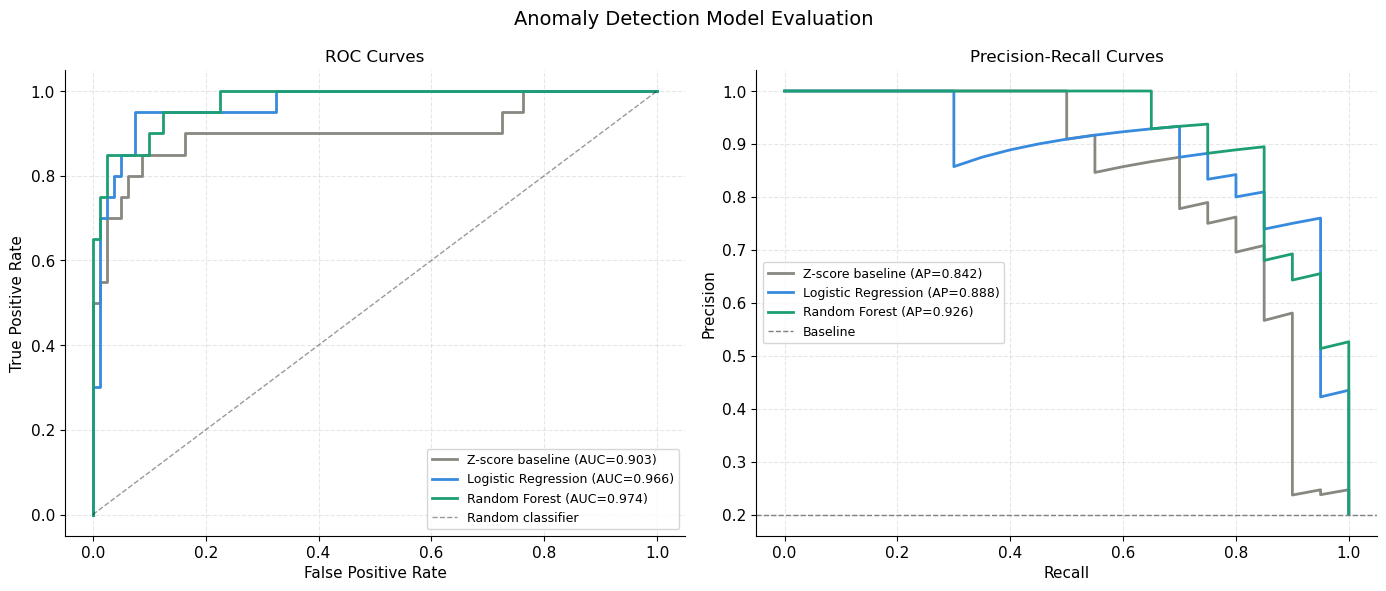

Saved: 06_roc_pr_curves.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Anomaly Detection Model Evaluation', fontsize=14, fontweight='500')

colors = ['#888780', '#378ADD', '#1D9E75']

# ROC curves
ax = axes[0]
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    auc = roc_auc_score(y_test, res['proba'])
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(fontsize=9)

# Precision-Recall
ax = axes[1]
for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['proba'])
    ap = average_precision_score(y_test, res['proba'])
    ax.plot(rec, prec, lw=2, color=color, label=f'{name} (AP={ap:.3f})')
ax.axhline(y_test.mean(), color='gray', lw=1, linestyle='--', label='Baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/plots/06_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_roc_pr_curves.png")


## 9. Confusion Matrices

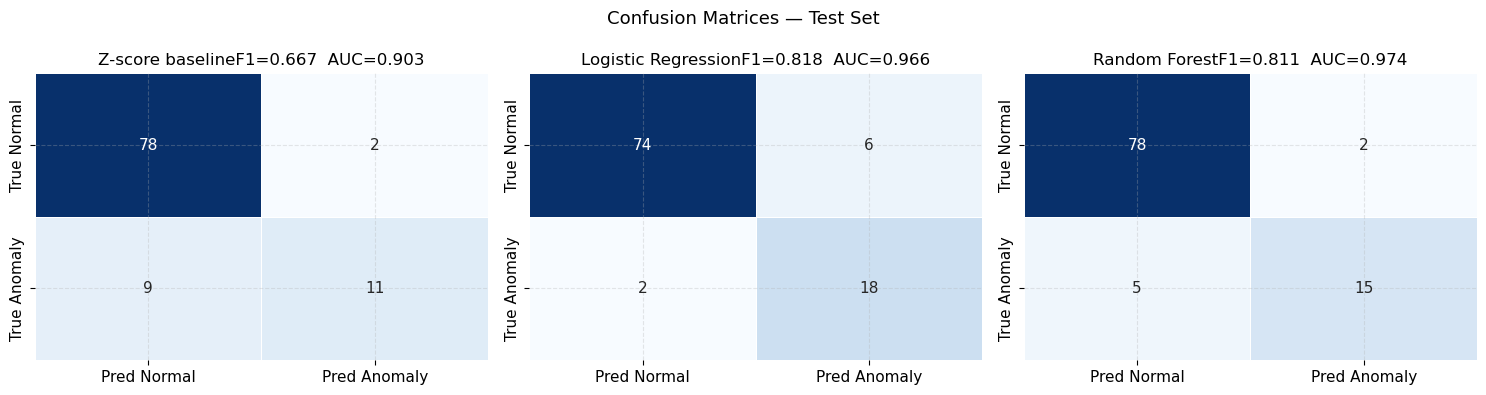

Saved: 07_confusion_matrices.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices — Test Set', fontsize=13)

for ax, (name, res), color in zip(axes, results.items(), colors):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['Pred Normal','Pred Anomaly'],
                yticklabels=['True Normal','True Anomaly'],
                linewidths=0.5)
    f1  = f1_score(y_test, res['pred'], zero_division=0)
    auc = roc_auc_score(y_test, res['proba'])
    ax.set_title(f'{name}F1={f1:.3f}  AUC={auc:.3f}')

plt.tight_layout()
plt.savefig('../results/plots/07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_confusion_matrices.png")


## 10. Feature Importance - Random Forest

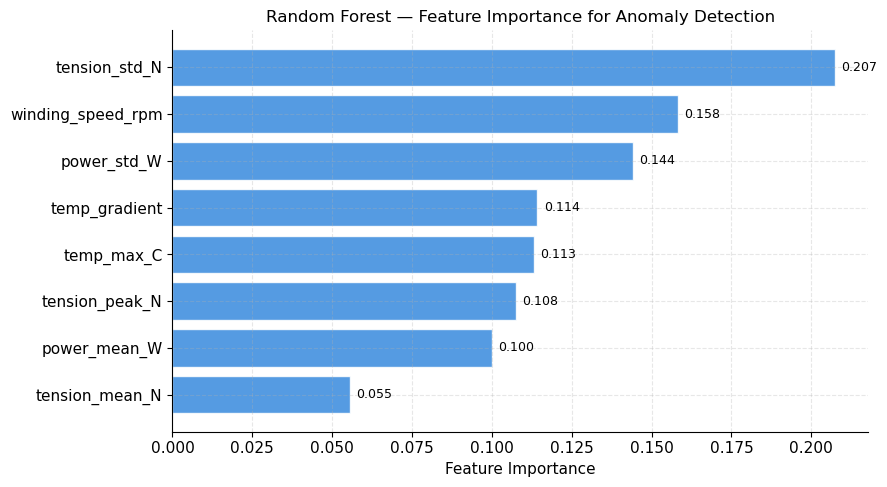

Saved: 08_feature_importance.png


In [26]:
importances = pd.Series(rf.feature_importances_, index=SIGNAL_FEATURES)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importances.index, importances.values,
               color='#378ADD', edgecolor='white', alpha=0.85)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — Feature Importance for Anomaly Detection')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/plots/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_feature_importance.png")


## 11. Cross-Validation — Random Forest

In [27]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

auc_scores = cross_val_score(rf, X_scaled, y, cv=skf, scoring='roc_auc', n_jobs=-1)
f1_scores  = cross_val_score(rf, X_scaled, y, cv=skf, scoring='f1',      n_jobs=-1)

print("5-Fold Cross-Validation — Random Forest:")
print(f"  AUC : {auc_scores.mean():.3f} +/- {auc_scores.std():.3f}")
print(f"  F1  : {f1_scores.mean():.3f} +/- {f1_scores.std():.3f}")
print()
print("Individual fold AUC scores:")
for i, score in enumerate(auc_scores, 1):
    print(f"  Fold {i}: {score:.3f}")


5-Fold Cross-Validation — Random Forest:
  AUC : 0.948 +/- 0.027
  F1  : 0.767 +/- 0.023

Individual fold AUC scores:
  Fold 1: 0.932
  Fold 2: 0.979
  Fold 3: 0.983
  Fold 4: 0.932
  Fold 5: 0.916


## 12. PCA Visualisation — 2D Anomaly Map

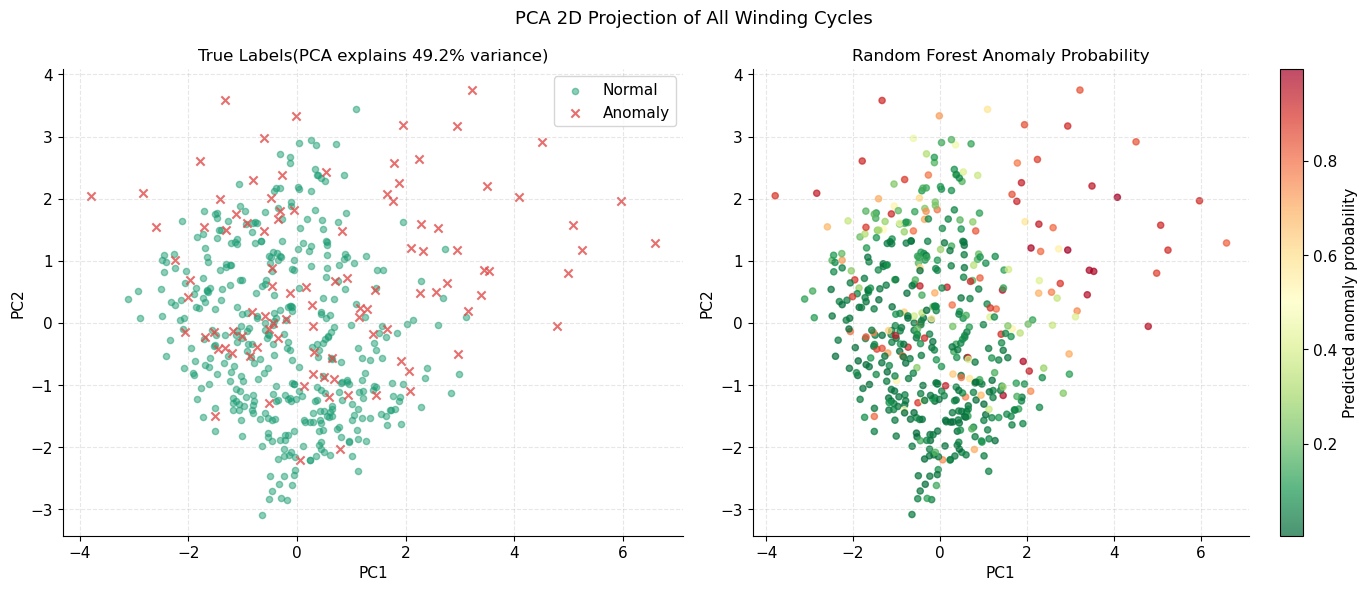

Saved: 09_pca_anomaly_map.png


In [29]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PCA 2D Projection of All Winding Cycles', fontsize=13)

# True labels
ax = axes[0]
ax.scatter(X_pca[y==0, 0], X_pca[y==0, 1],
           c='#1D9E75', s=20, alpha=0.5, label='Normal')
ax.scatter(X_pca[y==1, 0], X_pca[y==1, 1],
           c='#E24B4A', s=35, alpha=0.8, label='Anomaly', marker='x')
ax.set_title(f'True Labels(PCA explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()

# Random Forest predicted probability
ax = axes[1]
all_proba = rf.predict_proba(X_scaled)[:, 1]
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=all_proba, cmap='RdYlGn_r', s=20, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Predicted anomaly probability')
ax.set_title('Random Forest Anomaly Probability')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('../results/plots/09_pca_anomaly_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_pca_anomaly_map.png")


## 13. Summary

In [31]:
best = max(results, key=lambda m: roc_auc_score(y_test, results[m]['proba']))
best_auc = roc_auc_score(y_test, results[best]['proba'])
best_f1  = f1_score(y_test, results[best]['pred'], zero_division=0)

print("=" * 55)
print("ANOMALY DETECTION SUMMARY")
print("=" * 55)
print()
print("MODEL COMPARISON:")
for name, res in results.items():
    auc = roc_auc_score(y_test, res['proba'])
    f1  = f1_score(y_test, res['pred'], zero_division=0)
    print(f"  {name:<22} AUC={auc:.3f}  F1={f1:.3f}")
print()
print(f"Best model : {best}")
print(f"Best AUC   : {best_auc:.3f}")
print(f"Best F1    : {best_f1:.3f}")
print()
print("CV Results (Random Forest):")
print(f"  AUC : {auc_scores.mean():.3f} +/- {auc_scores.std():.3f}")
print(f"  F1  : {f1_scores.mean():.3f} +/- {f1_scores.std():.3f}")
print()


ANOMALY DETECTION SUMMARY

MODEL COMPARISON:
  Z-score baseline       AUC=0.903  F1=0.667
  Logistic Regression    AUC=0.966  F1=0.818
  Random Forest          AUC=0.974  F1=0.811

Best model : Random Forest
Best AUC   : 0.974
Best F1    : 0.811

CV Results (Random Forest):
  AUC : 0.948 +/- 0.027
  F1  : 0.767 +/- 0.023

